- GOAL      key on the five banked curves, toronto ladder on the time term, five refits on the winner, first map
- PRODUCED  key on each city's own grid: not inverted. cold side tracks in sign and shape, hot tail floats (se 2–6, MTL and OTT 2+ se high), mid-range wobble ±0.8 structured in MTL and VAN. tab1's spearman −0.9 was noise against the wrong ruler: key at p90 is at most 0.06, fit wobble there 0.3–0.5. ladder: dropping ns(t) moves the ends up 2.3 (5.6 → 7.9 cold), bias not precision; pooled poisson returns log of population-weighted mean RR, not the DA mean; key of record is now log-mean-RR; no-time rung lands on it at rms 0.35, df=20 at 0.87, attenuation shown in TOR and MTL, undetermined in VAN OTT QUE. spec stays df=20 today, phase 3 collapsed (red5 is that rung), pool §11.3 regenerated, toronto downscale at p95 vs own mmt, first map, log scale, sign −0.59 read not scored
- MISSED    predicted precision-only from dropping the spline, got 1.7 se bias: spline eats temperature signal. derived an information-weighted key (12.6 at 4°C), nowhere: poisson matches totals, totals are sums of exp. qaic across rungs uses each fit's own phi, not comparable. placed the mmt on toronto's basin, got tilt-driven mmt (median 22.6, q10 16.6): shallow basin, tilt decides. mean-of-per-DA-p80 sits below the pooled p80. data.table's key argument, sapply names on identical, j-loop at 8 not 7
- BANKED    saves_eod_2026-08-26: key_in, key5_v3, curves_v3, se5, ladder_tab, cma_bu, stage2_bu, th_bu, mmt_da, da_surface. fig3_map / fig_key5 / fig_ladder_tor pngs on drive
- NEXT      five cities on the no-time rung, rerun key5 and the map, that decides the spec. then amplitude: read tail vs identified half, dgp cold coefficient 0.01·Δ² is 10× epidemiology (ticket). push: §5.5 brace text, §11.6 rewrite (not inverted), §11.8 key + ladder + map, §4 flags: no-time candidate spec, compute_da_mmt needs Boundary.knots, save_to_drive unlink, qaic one phi.

restore. lib cache, packages, 06-03 session rdata, fns.R after, 07-22 named reads, 08-21 four objects into their own dir (tarball holds 31 not 4, no-unlink bug), rm imposter truth_factors. brace check on live simulate_counts: j-loop must hold 5 statements, lagged matrix must be the next top-level statement. predict landmines 0, 5/18, 31 rds, spearman −0.9

In [1]:
DRIVE <- "/content/drive/MyDrive/thesis/dlnm-pilot"

system(sprintf("tar -xzf '%s/r_library.tar.gz' -C /content", DRIVE))
.libPaths(c("/content/site-library", .libPaths()))
suppressPackageStartupMessages({
  library(dlnm); library(gnm); library(mixmeta); library(splines)
  library(sf); library(data.table); library(ggplot2); library(viridis); library(lubridate)
})

system(sprintf("tar -xzf '%s/saves_pilot_2026-06-03.tar.gz' -C /content", DRIVE))
rdata <- list.files("/content", pattern = "pilot_session\\.RData$", recursive = TRUE, full.names = TRUE)
stopifnot(length(rdata) == 1)
pre <- ls()
load(rdata)
loaded <- setdiff(ls(), c(pre, "pre", "rdata"))

source(file.path(DRIVE, "fns.R"))
if (exists("truth_factors")) rm(truth_factors)

system(sprintf("tar -xzf '%s/saves_eod_2026-07-22.tar.gz' -C /content", DRIVE))
EOD <- "/content/saves_eod"
red5           <- readRDS(file.path(EOD, "red5_v2.rds"))
res5           <- readRDS(file.path(EOD, "res5_v2.rds"))
Z_list         <- readRDS(file.path(EOD, "Z5_v2.rds"))
ids5           <- readRDS(file.path(EOD, "ids5_v2.rds"))
diag5          <- readRDS(file.path(EOD, "diag5_v2.rds"))
cma_predictors <- readRDS(file.path(EOD, "cma_predictors.rds"))
new_age        <- readRDS(file.path(EOD, "new_age_ottqc.rds"))
stage2_k5      <- readRDS(file.path(EOD, "stage2_k5_v2.rds"))$fit
mtl            <- readRDS(file.path(EOD, "mtl_substrate.rds"))
van            <- readRDS(file.path(EOD, "van_substrate.rds"))
cma_age_data_mtlvan <- readRDS(file.path(EOD, "cma_age_data_mtlvan.rds"))

dir.create("/content/eod0821", showWarnings = FALSE)
system(sprintf("tar -xzf '%s/saves_eod_2026-08-21.tar.gz' -C /content/eod0821", DRIVE))
E21 <- "/content/eod0821/saves_eod"
tab1        <- readRDS(file.path(E21, "tab1_p90_sign.rds"))
loadings_bu <- readRDS(file.path(E21, "loadings_bu.rds"))
c3_bu       <- readRDS(file.path(E21, "c3_bu.rds"))
pca_da_var  <- readRDS(file.path(E21, "pca_da_var.rds"))
"fn
need <- c("read_daymet","build_crossbasis","make_strata_A","make_strata_B","qaic",
          "fit_city_sliver","build_city_sim_substrate_v2","simulate_counts",
          "fit_stage1","reduce_fit","fit_stage2","fit_da_pca","predict_da_theta",
          "compute_da_mmt","monte_carlo_ci","standardize_da_rate","save_to_drive",
          "base_log_rr","make_choropleth")
fns_txt <- readLines(file.path(DRIVE, s.R"))
audit <- data.table(fn = need,
  in_env  = sapply(need, function(f) exists(f) && is.function(get(f))),
  in_file = sapply(need, function(f) any(grepl(sprintf("^%s <- function", f), fns_txt))))
audit[, landmine := in_env & !in_file]

cities <- c("Toronto","Montreal","Vancouver","Ottawa","Quebec")

b   <- as.list(body(simulate_counts))[-1]
top <- sapply(b, function(e) deparse(e)[1])
j_at <- which(grepl("^for \\(j in", top))
stopifnot(length(j_at) == 1)
n_in_loop <- length(b[[j_at]][[4]]) - 1

cat("landmines:", sum(audit$landmine), "\n")
cat("j-loop statements:", n_in_loop, "| top-level:", length(b),
    "| j-loop at", j_at, "| lagged at", which(grepl("^log_rr_lagged <- matrix", top)), "\n")
cat("tar 07-22 rds:", length(list.files(EOD, pattern = "\\.rds$")),
    "| tar 08-21 rds:", length(list.files(E21, pattern = "\\.rds$")), "\n")
cat("tab1 rows:", nrow(tab1), "| spearman:",
    round(cor(tab1$mean_truth, tab1$fit_p90, method = "spearman"), 3), "\n")
cat("red5 names:", names(red5), "\n")
cat("session objects:", length(loaded), "| truth_factors gone:", !exists("truth_factors"), "\n")
cat("da_age rows:", nrow(da_age), "| L:", paste(dim(L), collapse = " x "), "\n")

landmines: 0 
j-loop statements: 5 | top-level: 18 | j-loop at 8 | lagged at 9 
tar 07-22 rds: 27 | tar 08-21 rds: 31 
tab1 rows: 5 | spearman: -0.9 
red5 names: Toronto Montreal Vancouver Ottawa Quebec 
session objects: 47 | truth_factors gone: TRUE 
da_age rows: 7694 | L: 17 x 3 


landmines: 0
j-loop statements: 5 | top-level: 18 | j-loop at 8 | lagged at 9
tar 07-22 rds: 27 | tar 08-21 rds: 31
tab1 rows: 5 | spearman: -0.9
red5 names: Toronto Montreal Vancouver Ottawa Quebec
session objects: 47 | truth_factors gone: TRUE
da_age rows: 7694 | L: 17 x 3

---

landmines 0: nothing live that isn't in fns.R. j-loop 5 statements, lagged at the next slot: the brace is in the live function, only the SSOT §5.5 text drops it. 08-21 tarball holds 31 rds not 4: save_to_drive tars the un-emptied folder. spearman −0.9 reproduces tab1

regen five v2 substrates from the drive csvs at seed 42+offset, no fits. redo the sliver draw set.seed(42) sample 150, keep those rows only. fingerprint: sliver quantiles .1/.75/.9 == red5 basis knots, sliver median == red5 cen, both to 0. n_da and mu vs diag5

In [2]:
seeds <- c(Toronto = 35, Montreal = 24, Vancouver = 59, Ottawa = 63, Quebec = 421)
csvs  <- c(Toronto = "toronto_daymet_2015_2019.csv",  Montreal = "montreal_daymet_2015_2019.csv",
           Vancouver = "vancouver_daymet_2015_2019.csv", Ottawa = "ottawa_daymet_2015_2019.csv",
           Quebec = "quebec_daymet_2015_2019.csv")
ages  <- list(Toronto = da_age, Montreal = cma_age_data_mtlvan$montreal,
              Vancouver = cma_age_data_mtlvan$vancouver,
              Ottawa = new_age$Ottawa, Quebec = new_age$Quebec)
f3 <- function(x) paste(sprintf("%6.3f", x), collapse = " ")

sliv <- list()
for (cc in cities) {
  dm  <- read_daymet(file.path(DRIVE, csvs[cc]))
  sub <- build_city_sim_substrate_v2(dm, ages[[cc]], L, seed = 42 + seeds[cc])
  rm(dm)
  stopifnot(all(rownames(sub$temp_mat) == sub$truth_factors$DAUID))
  stopifnot(identical(sub$truth_factors$DAUID, ids5[[cc]]))

  set.seed(42)
  idx <- sample(1:sub$n_da, 150)
  tm  <- sub$temp_mat[idx, ]
  tf  <- sub$truth_factors[idx]
  stopifnot(nrow(tm) == 150, sum(is.na(tm)) == 0)

  kn_now <- unname(quantile(as.vector(tm), c(0.10, 0.75, 0.90)))
  kn_bnk <- unname(attr(red5[[cc]]$reduced_obj$basis, "knots"))
  cen    <- red5[[cc]]$cen
  d <- if (is.data.table(diag5)) diag5[cma == cc] else diag5[[cc]]

  cat(sprintf("%-9s n_da %5d/%5d  mu %s | %s  knots dmax %.0e  cen %.2f diff %.0e\n",
              cc, sub$n_da, d$n_da, f3(sub$mu), f3(c(d$mu1, d$mu2, d$mu3)),
              max(abs(kn_now - kn_bnk)), cen, abs(median(as.vector(tm)) - cen)))

  sliv[[cc]] <- list(idx = idx, temp = tm, tf = tf, cen = cen, knots = kn_bnk,
                     mmt = apply(tm, 1, function(x) unname(quantile(x, 0.80))))
  if (cc == "Toronto") tor_sub <- sub
  rm(sub); invisible(gc(verbose = FALSE))
}
cat("sliv cities:", length(sliv), "| tor_sub kept:", exists("tor_sub"), "\n")

Toronto   n_da  7682/ 7682  mu -0.330  0.655  0.384 | -0.330  0.655  0.384  knots dmax 0e+00  cen 19.38 diff 0e+00
Montreal  n_da  6504/ 6504  mu  1.394  0.130  0.251 |  1.394  0.130  0.251  knots dmax 0e+00  cen 19.01 diff 0e+00
Vancouver n_da  3573/ 3573  mu -0.196  0.331 -0.405 | -0.196  0.331 -0.405  knots dmax 0e+00  cen 17.05 diff 0e+00
Ottawa    n_da  2042/ 2042  mu -0.776 -0.280  0.080 | -0.776 -0.280  0.080  knots dmax 0e+00  cen 18.58 diff 0e+00
Quebec    n_da  1310/ 1310  mu -0.077 -1.059  0.200 | -0.077 -1.059  0.200  knots dmax 0e+00  cen 16.79 diff 0e+00
sliv cities: 5 | tor_sub kept: TRUE 


Toronto   n_da  7682/ 7682  mu -0.330  0.655  0.384 | -0.330  0.655  0.384  knots dmax 0e+00  cen 19.38 diff 0e+00
Montreal  n_da  6504/ 6504  mu  1.394  0.130  0.251 |  1.394  0.130  0.251  knots dmax 0e+00  cen 19.01 diff 0e+00
Vancouver n_da  3573/ 3573  mu -0.196  0.331 -0.405 | -0.196  0.331 -0.405  knots dmax 0e+00  cen 17.05 diff 0e+00
Ottawa    n_da  2042/ 2042  mu -0.776 -0.280  0.080 | -0.776 -0.280  0.080  knots dmax 0e+00  cen 18.58 diff 0e+00
Quebec    n_da  1310/ 1310  mu -0.077 -1.059  0.200 | -0.077 -1.059  0.200  knots dmax 0e+00  cen 16.79 diff 0e+00
sliv cities: 5 | tor_sub kept: TRUE  

---

all five knot and cen diffs exactly zero: sliv holds the same 150 DAs and 114,750 temperatures each banked curve was fit on. n_da and mu match diag5 row for row

key inputs per city from sliv: cen from red5, per-DA p80 mmt (mean min max), sliver means of F1 F2 F3 with the largest gap to mu, and cen below every DA's mmt

In [3]:
key_in <- rbindlist(lapply(cities, function(cc) {
  s  <- sliv[[cc]]
  Fm <- colMeans(as.matrix(s$tf[, .(F1, F2, F3)]))
  mu <- unlist(diag5[cma == cc, .(mu1, mu2, mu3)])
  data.table(city = cc, cen = round(s$cen, 2),
             mmt_mean = round(mean(s$mmt), 2),
             mmt_min = round(min(s$mmt), 1), mmt_max = round(max(s$mmt), 1),
             F1 = round(Fm[1], 2), F2 = round(Fm[2], 2), F3 = round(Fm[3], 2),
             dmax = round(max(abs(Fm - mu)), 2))
}))
print(key_in)
cat("cen < mmt_min everywhere:", all(key_in$cen < key_in$mmt_min), "\n")

        city   cen mmt_mean mmt_min mmt_max    F1    F2    F3  dmax
      <char> <num>    <num>   <num>   <num> <num> <num> <num> <num>
1:   Toronto 19.38    22.76    21.1    23.5 -0.34  0.63  0.37  0.03
2:  Montreal 19.01    22.31    21.1    22.5  1.38 -0.02  0.18  0.15
3: Vancouver 17.05    19.48    18.9    20.3 -0.42  0.19 -0.30  0.22
4:    Ottawa 18.58    21.86    20.9    22.1 -0.72 -0.17  0.08  0.11
5:    Quebec 16.79    20.22    19.0    20.7 -0.13 -1.03  0.13  0.07
cen < mmt_min everywhere: TRUE 


  city   cen mmt_mean mmt_min mmt_max    F1    F2    F3  dmax
      <char> <num>    <num>   <num>   <num> <num> <num> <num> <num>
1:   Toronto 19.38    22.76    21.1    23.5 -0.34  0.63  0.37  0.03
2:  Montreal 19.01    22.31    21.1    22.5  1.38 -0.02  0.18  0.15
3: Vancouver 17.05    19.48    18.9    20.3 -0.42  0.19 -0.30  0.22
4:    Ot tawa 18.58    21.86    20.9    22.1 -0.72 -0.17  0.08  0.11
5:    Quebec 16.79    20.22    19.0    20.7 -0.13 -1.03  0.13  0.07
cen < mmt_min everywhere: TRUE

---

cen sits 2.4 to 3.5°C below each city's mean mmt and below the lowest mmt in every city, so the centering point is on the cold side of every DA's curve. sliver F means within 0.22 of mu, largest gaps VAN and MTL, ordinary for 150 draws


key curve per city: sliver mean of base_log_rr(T, mmt_i)·mod_i(T) − same at cen, heat mod exp(0.4F1+0.2F3) above mmt_i, cold mod exp(0.3F2+0.2F3) below, on each city's own predvar grid. five panels key line vs red5 fit points, shared y. table at the grid point nearest knot3, gap, ratio, key min, both curves at the grid ends, spearman across cities

        city   T90 key_p90 fit_p90    gap ratio key_min key_cold key_hot
      <char> <num>   <num>   <num>  <num> <num>   <num>    <num>   <num>
1:   Toronto  24.5  -0.060   0.261  0.321  -4.3  -0.156     4.72    1.45
2:  Montreal  24.0   0.047  -0.851 -0.898 -18.0  -0.120     4.47    2.13
3: Vancouver  21.0   0.002   0.689  0.687 373.8  -0.061     1.86    1.45
4:    Ottawa  23.5  -0.042   0.458  0.500 -11.0  -0.110     4.16    1.01
5:    Quebec  21.5  -0.040  -0.136 -0.096   3.4  -0.094     2.61    1.16
   fit_cold fit_hot
      <num>   <num>
1:     5.60    1.98
2:     0.49    5.91
3:     4.62    3.85
4:     6.46    6.72
5:     4.65   -3.89
spearman(key_p90, fit_p90): -0.3 
right sign at p90: 2 / 5


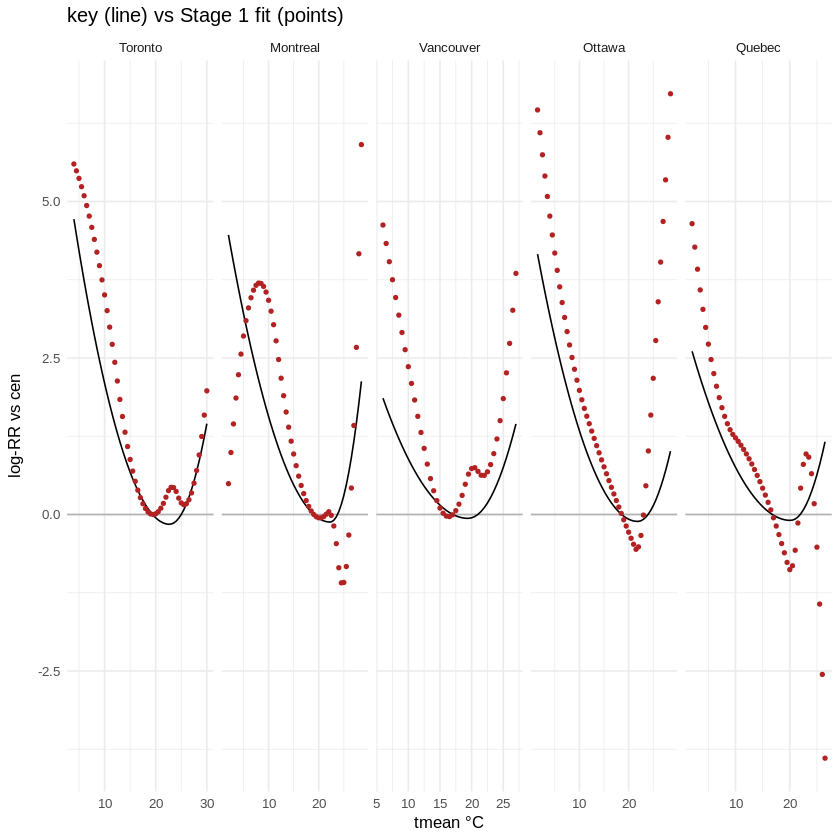

In [5]:
key_curve <- function(s, grid) {
  F1 <- s$tf$F1; F2 <- s$tf$F2; F3 <- s$tf$F3; mmt <- unname(s$mmt)
  mod_h <- exp(0.4*F1 + 0.2*F3)
  mod_c <- exp(0.3*F2 + 0.2*F3)
  g  <- function(Tt) base_log_rr(Tt, mmt) * ifelse(Tt > mmt, mod_h, mod_c)
  g0 <- g(s$cen)
  sapply(grid, function(Tt) mean(g(Tt) - g0))
}

curves <- list(); key5 <- list()
for (cc in cities) {
  r <- red5[[cc]]$reduced_obj; s <- sliv[[cc]]
  k <- key_curve(s, r$predvar)
  stopifnot(length(k) == length(r$fit), sum(is.na(k)) == 0,
            abs(k[which.min(abs(r$predvar - s$cen))]) < 0.05)
  i90 <- which.min(abs(r$predvar - s$knots[3]))
  n   <- length(k)
  curves[[cc]] <- data.table(city = cc, temp = r$predvar, key_lr = k, fit = r$fit)
  key5[[cc]] <- data.table(city = cc, T90 = r$predvar[i90],
                           key_p90 = round(k[i90], 3), fit_p90 = round(r$fit[i90], 3),
                           gap = round(r$fit[i90] - k[i90], 3),
                           ratio = round(r$fit[i90] / k[i90], 1),
                           key_min = round(min(k), 3),
                           key_cold = round(k[1], 2), key_hot = round(k[n], 2),
                           fit_cold = round(r$fit[1], 2), fit_hot = round(r$fit[n], 2))
}
curves <- rbindlist(curves); key5 <- rbindlist(key5)
curves[, city := factor(city, levels = cities)]

p_key <- ggplot(curves, aes(temp)) +
  geom_hline(yintercept = 0, colour = "grey70") +
  geom_line(aes(y = key_lr), colour = "black") +
  geom_point(aes(y = fit), colour = "firebrick", size = 0.9) +
  facet_wrap(~ city, nrow = 1, scales = "free_x") +
  labs(x = "tmean °C", y = "log-RR vs cen", title = "key (line) vs Stage 1 fit (points)") +
  theme_minimal(base_size = 10)
ggsave("/content/fig_key5.png", p_key, width = 12, height = 3.2, dpi = 130)
print(p_key)

print(key5)
cat("spearman(key_p90, fit_p90):",
    round(cor(key5$key_p90, key5$fit_p90, method = "spearman"), 3), "\n")
cat("right sign at p90:", sum(sign(key5$key_p90) == sign(key5$fit_p90)), "/ 5\n")

    city   T90 key_p90 fit_p90    gap ratio key_min key_cold key_hot
      <char> <num>   <num>   <num>  <num> <num>   <num>    <num>   <num>
1:   Toronto  24.5  -0.060   0.261  0.321  -4.3  -0.156     4.72    1.45
2:  Montreal  24.0   0.047  -0.851 -0.898 -18.0  -0.120     4.47    2.13
3: Vancouver  21.0   0.002   0.689  0.687 373.8  -0.061     1.86    1.45
4:    Ottawa  23.5  -0.042   0.458  0.500 -11.0  -0.110     4.16    1.01
5:    Quebec  21.5  -0.040  -0.136 -0.096   3.4  -0.094     2.61    1.16
   fit_cold fit_hot
      <num>   <num>
1:     5.60    1.98
2:     0.49    5.91
3:     4.62    3.85
4:     6.46    6.72
5:     4.65   -3.89
spearman(key_p90, fit_p90): -0.3
right sign at p90: 2 / 5

---
à
key vs fit on the full grid. cold half: same U, same sign, right size in the middle, 1.2 to 2.4× too steep at the far cold ends. hot tail past p90: fits swing −3.9 to +6.7 against keys of 1.0 to 2.1. key at p90 is at most 0.06 in absolute value, fit wobble there is ±0.5, so tab1's spearman −0.9 read noise against the wrong ruler. not inverted. cold side tracks, hot tail floats

fit's own se from reduced_obj$se at cen, p90, both grid ends, z = fit/se each. rms of fit minus key on the cold half (temp ≤ cen) and hot half (temp > cen) per city from the saved curves

In [6]:
stopifnot("se" %in% names(red5$Toronto$reduced_obj))
se5 <- rbindlist(lapply(cities, function(cc) {
  r <- red5[[cc]]$reduced_obj; s <- sliv[[cc]]; n <- length(r$fit)
  i90 <- which.min(abs(r$predvar - s$knots[3]))
  ic  <- which.min(abs(r$predvar - s$cen))
  cv  <- curves[city == cc]
  data.table(city = cc,
             se_cen = round(r$se[ic], 2),
             se_p90 = round(r$se[i90], 2), z_p90 = round(r$fit[i90] / r$se[i90], 1),
             se_cold = round(r$se[1], 2),  z_cold = round(r$fit[1] / r$se[1], 1),
             se_hot  = round(r$se[n], 2),  z_hot  = round(r$fit[n] / r$se[n], 1),
             rms_cold = round(sqrt(mean((cv$fit - cv$key_lr)[cv$temp <= s$cen]^2)), 2),
             rms_hot  = round(sqrt(mean((cv$fit - cv$key_lr)[cv$temp >  s$cen]^2)), 2))
}))
print(se5)
cat("|z_p90| < 2 in:", sum(abs(se5$z_p90) < 2), "/ 5 | |z_hot| < 2 in:", sum(abs(se5$z_hot) < 2), "/ 5\n")

        city se_cen se_p90 z_p90 se_cold z_cold se_hot z_hot rms_cold rms_hot
      <char>  <num>  <num> <num>   <num>  <num>  <num> <num>    <num>   <num>
1:   Toronto   0.01   0.45   0.6    1.38    4.1   5.50   0.4     1.01    0.31
2:  Montreal   0.00   0.34  -2.5    1.93    0.3   1.68   3.5     1.46    1.24
3: Vancouver   0.00   0.28   2.5    3.65    1.3   3.38   1.1     1.44    1.03
4:    Ottawa   0.01   0.28   1.6    2.25    2.9   2.32   2.9     1.05    2.60
5:    Quebec   0.01   0.32  -0.4    1.61    2.9   2.84  -1.4     0.83    1.56
|z_p90| < 2 in: 3 / 5 | |z_hot| < 2 in: 3 / 5


city se_cen se_p90 z_p90 se_cold z_cold se_hot z_hot rms_cold rms_hot
      <char>  <num>  <num> <num>   <num>  <num>  <num> <num>    <num>   <num>
1:   Toronto   0.01   0.45   0.6    1.38    4.1   5.50   0.4     1.01    0.31
2:  Montreal   0.00   0.34  -2.5    1.93    0.3   1.68   3.5     1.46    1.24
3: Vancouver   0.00   0.28   2.5    3.65    1.3   3.38   1.1     1.44    1.03
4:    Ottawa   0.01   0.28   1.6    2.25    2.9   2.32   2.9     1.05    2.60
5:    Quebec   0.01   0.32  -0.4    1.61    2.9   2.84  -1.4     0.83    1.56
|z_p90| < 2 in: 3 / 5 | |z_hot| < 2 in: 3 / 5

---

se at p90 0.28 to 0.45, z inside ±2 in three cities, MTL −2.5 and VAN +2.5: the mid-range wobble has a structured part, not noise alone. hot ends: MTL and OTT 2+ se above the key, TOR VAN QUE within noise. rms cold 0.8 to 1.5 because the fit runs ~20% steep across the whole cold side. rms hot: TOR 0.31 quietest, OTT 2.60 worst. baseline for the ladder: TOR rms_cold 1.01, rms_hot 0.31

run_city's first half inline on tor_sub: per-DA p80 mmt, da_long with lambda0, simulate_counts seed 42, same 150-DA draw, age 75_84, temps attached, crossbasis, vector-only frame. sim dropped, sliver kept. receipts: deaths vs diag5, knots, cb bit-identical to banked cb_template

In [7]:
sub <- tor_sub
mmt_tor <- apply(sub$temp_mat, 1, function(x) quantile(x, 0.80, na.rm = TRUE))

dal <- CJ(da_idx = 1:sub$n_da, date = study_dates, age_band = names(annual_rates))
pl  <- melt(sub$da_age[, .(da_idx, age_0_64, age_65_74, age_75_84, age_85p)],
            id.vars = "da_idx", variable.name = "age_band", value.name = "pop")
pl[, age_band := as.character(age_band)]
dal <- pl[dal, on = c("da_idx","age_band")]
dal[, annual_rate := annual_rates[age_band]]
dal[, lambda0 := pop * annual_rate / 1000 / 365]
stopifnot(sum(is.na(dal$pop)) == 0)

sim <- simulate_counts(sub$temp_mat, dal, sub$truth_factors, mmt_tor, seed = 42)
rm(dal, pl); invisible(gc(verbose = FALSE))
tot <- sum(sim$n_deaths)

set.seed(42)
idx <- sample(unique(sim$da_idx), 150)
stopifnot(identical(as.integer(idx), as.integer(sliv$Toronto$idx)))
sl <- sim[da_idx %in% idx & age_band == "age_75_84"]
sl[, DA_id := da_idx]
setorder(sl, da_idx, date)
rm(sim); invisible(gc(verbose = FALSE))

tl <- data.table(da_idx = rep(idx, each = length(study_dates)),
                 date   = rep(study_dates, times = 150),
                 temp_C = as.vector(t(sub$temp_mat[idx, ])))
sl <- tl[sl, on = c("da_idx","date")]
stopifnot(nrow(sl) == 150 * length(study_dates), sum(is.na(sl$temp_C)) == 0)

cb_tor <- build_crossbasis(sl$temp_C, lag_max = 21)
dt_tor <- data.table(n_deaths = sl$n_deaths, DA_id = sl$DA_id, date = sl$date)
stopifnot(nrow(dt_tor) == nrow(cb_tor))

cat("total deaths:", tot, "| sliver deaths:", sum(sl$n_deaths),
    "| diag5:", diag5[cma == "Toronto"]$sliver_deaths, "\n")
cat("cb:", paste(dim(cb_tor), collapse = " x "),
    "| knots dmax:", max(abs(unname(attr(cb_tor, "argvar")$knots) - sliv$Toronto$knots)), "\n")
cat("cb identical to banked:",
    isTRUE(all.equal(unclass(cb_tor), unclass(res5$Toronto$cb_template), check.attributes = FALSE)), "\n")

total deaths: 610216 | sliver deaths: 2419 | diag5: 2419 
cb: 114750 x 25 | knots dmax: 0 
cb identical to banked: TRUE 


total deaths: 610216 | sliver deaths: 2419 | diag5: 2419
cb: 114750 x 25 | knots dmax: 0
cb identical to banked: TRUE

---

610,216 deaths, 2,419 in the sliver, both diag5's numbers. cb 114,750 × 25, knots zero off, matrix bit-identical to the banked cb_template. dt_tor and cb_tor are the exact Stage 1 input of 07-22

fit_rung: fit_stage1 variant A only, time term as argument, gnm with eliminate strata_A. score_rung: crossreduce at cen on the key's grid, one row: qaic, p90 and se, grid ends, rms gap to key cold and hot. rung 2a ns(t, df=20) must reproduce the banked numbers

In [8]:
fit_rung <- function(dt, cb_template, time_term) {
  cb <- cb_template
  d  <- copy(dt)
  d[, strata_A := make_strata_A(DA_id, date)]
  d[, dow := factor(wday(date))]
  d[, t   := as.integer(date - min(date)) + 1]
  rhs  <- if (nzchar(time_term)) paste("cb + dow +", time_term) else "cb + dow"
  form <- as.formula(paste("n_deaths ~", rhs))
  fit  <- gnm(form, data = d, family = quasipoisson(), eliminate = strata_A)
  stopifnot(isTRUE(fit$converged))
  fit
}

score_rung <- function(fit, cb_template, s, key_dt, label) {
  cb_idx <- grep("^cb", names(coef(fit)))
  stopifnot(length(cb_idx) == 25)
  red <- crossreduce(cb_template, coef = coef(fit)[cb_idx], vcov = vcov(fit)[cb_idx, cb_idx],
                     model.link = "log", type = "overall", cen = s$cen)
  stopifnot(isTRUE(all.equal(red$predvar, key_dt$temp)))
  n   <- length(red$fit)
  i90 <- which.min(abs(red$predvar - s$knots[3]))
  gap <- red$fit - key_dt$key_lr
  row <- data.table(rung = label, qaic = round(qaic(fit), 1),
                    p90 = round(red$fit[i90], 3), se_p90 = round(red$se[i90], 2),
                    key_p90 = round(key_dt$key_lr[i90], 3),
                    cold_end = round(red$fit[1], 2), hot_end = round(red$fit[n], 2),
                    rms_cold = round(sqrt(mean(gap[red$predvar <= s$cen]^2)), 2),
                    rms_hot  = round(sqrt(mean(gap[red$predvar >  s$cen]^2)), 2),
                    conv = isTRUE(fit$converged))
  list(row = row, red = red)
}

key_tor <- curves[city == "Toronto"]
ladder  <- list()
fit_a   <- fit_rung(dt_tor, cb_tor, "ns(t, df = 20)")
ladder[["ns df=20"]] <- score_rung(fit_a, cb_tor, sliv$Toronto, key_tor, "ns df=20")
print(ladder[["ns df=20"]]$row)

       rung  qaic   p90 se_p90 key_p90 cold_end hot_end rms_cold rms_hot   conv
     <char> <num> <num>  <num>   <num>    <num>   <num>    <num>   <num> <lgcl>
1: ns df=20 27047 0.261   0.45   -0.06      5.6    1.98     1.01    0.31   TRUE


rung  qaic   p90 se_p90 key_p90 cold_end hot_end rms_cold rms_hot   conv
     <char> <num> <num>  <num>   <num>    <num>   <num>    <num>   <num> <lgcl>
1: ns df=20 27047 0.261   0.45   -0.06      5.6    1.98     1.01    0.31   TRUE

---

rung 2a reproduces the banked toronto curve to every digit: qaic 27047, p90 0.261, se 0.45, ends 5.6 / 1.98, rms 1.01 / 0.31. fit_rung is fit_stage1 variant A. the ladder stands on the same ground as 07-22

rungs 2b ns(t, df=3) and 2c no time term, strata carry season. same score, three rows, one figure key line vs three rungs. rule fixed before the run: lowest rms_hot wins, within 0.1 of each other lowest qaic wins, rms_cold must not worsen

       rung    qaic   p90 se_p90 key_p90 cold_end hot_end rms_cold rms_hot
     <char>   <num> <num>  <num>   <num>    <num>   <num>    <num>   <num>
1: ns df=20 27047.0 0.261   0.45   -0.06     5.60    1.98     1.01    0.31
2:  ns df=3 27051.5 0.084   0.34   -0.06     7.46    4.66     1.37    1.06
3:  no time 26859.3 0.069   0.34   -0.06     7.93    4.39     1.50    0.97
     conv
   <lgcl>
1:   TRUE
2:   TRUE
3:   TRUE
spread rms_hot: 0.75 | winner by rule: ns df=20 


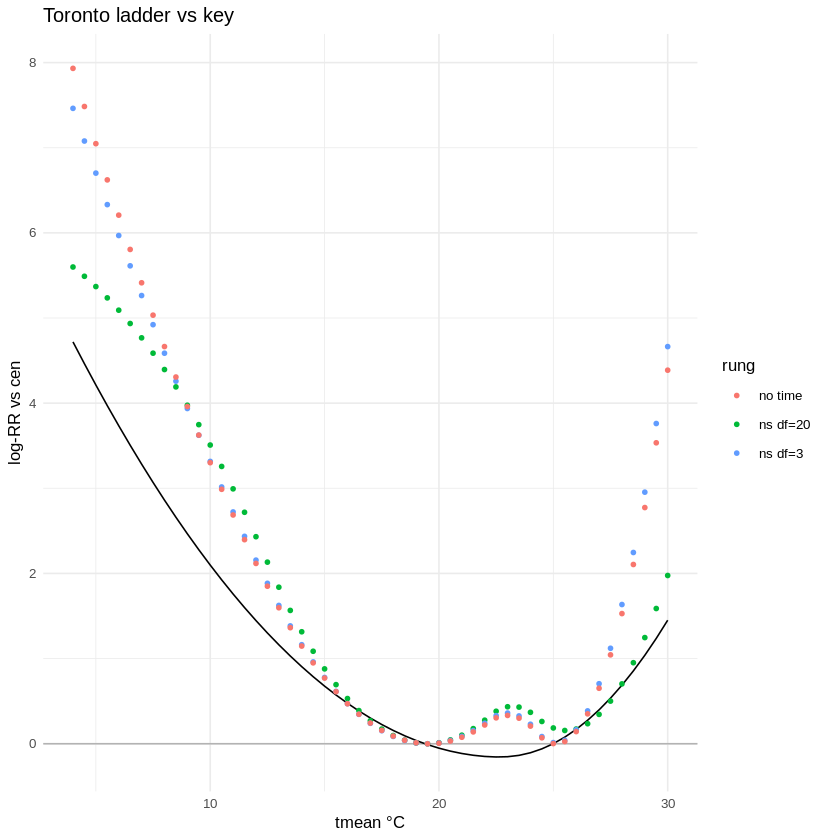

In [9]:
fit_b <- fit_rung(dt_tor, cb_tor, "ns(t, df = 3)")
ladder[["ns df=3"]] <- score_rung(fit_b, cb_tor, sliv$Toronto, key_tor, "ns df=3")
fit_c <- fit_rung(dt_tor, cb_tor, "")
ladder[["no time"]] <- score_rung(fit_c, cb_tor, sliv$Toronto, key_tor, "no time")

ladder_tab <- rbindlist(lapply(ladder, `[[`, "row"))
print(ladder_tab)

rung_pts <- rbindlist(lapply(names(ladder), function(nm)
  data.table(rung = nm, temp = ladder[[nm]]$red$predvar, fit = ladder[[nm]]$red$fit)))
p_lad <- ggplot() +
  geom_hline(yintercept = 0, colour = "grey70") +
  geom_line(data = key_tor, aes(temp, key_lr), colour = "black") +
  geom_point(data = rung_pts, aes(temp, fit, colour = rung), size = 1) +
  labs(x = "tmean °C", y = "log-RR vs cen", title = "Toronto ladder vs key") +
  theme_minimal(base_size = 10)
ggsave("/content/fig_ladder_tor.png", p_lad, width = 7, height = 4, dpi = 130)
print(p_lad)

win <- ladder_tab[order(rms_hot, qaic)][1, rung]
cat("spread rms_hot:", round(diff(range(ladder_tab$rms_hot)), 2),
    "| winner by rule:", win, "\n")

rung    qaic   p90 se_p90 key_p90 cold_end hot_end rms_cold rms_hot
     <char>   <num> <num>  <num>   <num>    <num>   <num>    <num>   <num>
1: ns df=20 27047.0 0.261   0.45   -0.06     5.60    1.98     1.01    0.31
2:  ns df=3 27051.5 0.084   0.34   -0.06     7.46    4.66     1.37    1.06
3:  no time 26859.3 0.069   0.34   -0.06     7.93    4.39     1.50    0.97
     conv
   <lgcl>
1:   TRUE
2:   TRUE
3:   TRUE
spread rms_hot: 0.75 | winner by rule: ns df=20

---

dropping the time spline moves the ends up, not sideways: cold end 5.6 → 7.5 / 7.9, hot end 2.0 → 4.7 / 4.4, key 4.7 / 1.45. bias, 1.7 se. the spline attenuates the temperature signal; without it the fit shows the pooled estimand, which is a deaths-weighted mean of the DA curves, above the plain mean by about the variance of the DA curves. qaic not comparable across rungs: each fit uses its own phi. rule: df=20 wins on rms_hot 0.31 vs 0.97 / 1.06. spec stays at df=20, red5 is already that rung

three keys on the toronto sliver from the same g_i: plain mean, log of lambda0-weighted mean RR, information-weighted mean (sum lambda0 e^g g / sum lambda0 e^g). read at cold end, p90, hot end next to the df=20 and no-time fits. rms on the cold half of each fit vs each key

In [10]:
s <- sliv$Toronto
stopifnot(all(tor_sub$da_age$ALT_GEO_CODE[s$idx] == s$tf$DAUID))
cat("aligned: TRUE\n")
lam <- tor_sub$da_age$age_75_84[s$idx]
F1 <- s$tf$F1; F2 <- s$tf$F2; F3 <- s$tf$F3; mmt <- unname(s$mmt)
mod_h <- exp(0.4*F1 + 0.2*F3); mod_c <- exp(0.3*F2 + 0.2*F3)
g <- function(Tt) base_log_rr(Tt, mmt) * ifelse(Tt > mmt, mod_h, mod_c)
g0 <- g(s$cen)
keys3 <- function(Tt) {
  gi <- g(Tt)
  c(mean  = mean(gi - g0),
    logRR = log(sum(lam * exp(gi)) / sum(lam)) - log(sum(lam * exp(g0)) / sum(lam)),
    info  = sum(lam * exp(gi) * gi) / sum(lam * exp(gi)) -
            sum(lam * exp(g0) * g0) / sum(lam * exp(g0)))
}
K <- as.data.table(t(sapply(key_tor$temp, keys3)))
K[, temp := key_tor$temp]
f20 <- ladder[["ns df=20"]]$red$fit; fno <- ladder[["no time"]]$red$fit
i90 <- which.min(abs(key_tor$temp - s$knots[3])); n <- nrow(K)
show <- K[c(1, i90, n), .(temp, key_mean = round(mean, 2), key_logRR = round(logRR, 2),
                          key_info = round(info, 2))]
show[, fit_df20 := round(f20[c(1, i90, n)], 2)]
show[, fit_none := round(fno[c(1, i90, n)], 2)]
print(show)
cold <- key_tor$temp <= s$cen
rms <- function(f, k) round(sqrt(mean((f - k)[cold]^2)), 2)
cat("rms cold no-time vs keys:", rms(fno, K$mean), rms(fno, K$logRR), rms(fno, K$info), "\n")
cat("rms cold df=20   vs keys:", rms(f20, K$mean), rms(f20, K$logRR), rms(f20, K$info), "\n")

aligned: TRUE
    temp key_mean key_logRR key_info fit_df20 fit_none
   <num>    <num>     <num>    <num>    <num>    <num>
1:   4.0     4.72      8.39    12.63     5.60     7.93
2:  24.5    -0.06     -0.07    -0.07     0.26     0.07
3:  30.0     1.45      1.70     2.05     1.98     4.39
rms cold no-time vs keys: 1.5 0.35 1.71 
rms cold df=20   vs keys: 1.01 0.87 2.44 


aligned: TRUE
    temp key_mean key_logRR key_info fit_df20 fit_none
   <num>    <num>     <num>    <num>    <num>    <num>
1:   4.0     4.72      8.39    12.63     5.60     7.93
2:  24.5    -0.06     -0.07    -0.07     0.26     0.07
3:  30.0     1.45      1.70     2.05     1.98     4.39
rms cold no-time vs keys: 1.5 0.35 1.71
rms cold df=20   vs keys: 1.01 0.87 2.44

---

---
three keys agree at p90 (−0.06 / −0.07 / −0.07), spread at the cold end 4.72 / 8.39 / 12.63. no-time rung lands on key_logRR at rms 0.35, df=20 at 0.87: the pooled poisson fit returns the log of the population-weighted mean RR because it matches total counts, and the 20-df spline attenuates that by a third at the cold end. key_info was a wrong derivation, nowhere. key of record from here: key_logRR. cold effect log-RR 8.4 at 4°C is a DGP amplitude thing

key of record: log of lambda0-weighted mean RR per city on the sliver, lambda0 from age_75_84 pop matched by DAUID into the city age table. curves and key5 replaced with v3, mean key kept as a column. table: both keys at the cold end, fit, ratio, p90, hot end, rms both halves vs the new key

In [11]:
key_logrr <- function(s, lam, grid) {
  F1 <- s$tf$F1; F2 <- s$tf$F2; F3 <- s$tf$F3; mmt <- unname(s$mmt)
  mod_h <- exp(0.4*F1 + 0.2*F3); mod_c <- exp(0.3*F2 + 0.2*F3)
  g  <- function(Tt) base_log_rr(Tt, mmt) * ifelse(Tt > mmt, mod_h, mod_c)
  l0 <- log(sum(lam * exp(g(s$cen))) / sum(lam))
  sapply(grid, function(Tt) log(sum(lam * exp(g(Tt))) / sum(lam)) - l0)
}

unm <- integer(0); curves_v3 <- list(); key5_v3 <- list()
for (cc in cities) {
  r <- red5[[cc]]$reduced_obj; s <- sliv[[cc]]
  m <- match(s$tf$DAUID, ages[[cc]]$ALT_GEO_CODE)
  unm[cc] <- sum(is.na(m))
  lam <- ages[[cc]]$age_75_84[m]
  stopifnot(sum(is.na(lam)) == 0, all(lam >= 0))
  kmean <- curves[city == cc, key_lr]
  klog  <- key_logrr(s, lam, r$predvar)
  stopifnot(length(klog) == length(r$fit), abs(klog[which.min(abs(r$predvar - s$cen))]) < 0.05)
  n <- length(klog); i90 <- which.min(abs(r$predvar - s$knots[3]))
  gap <- r$fit - klog
  curves_v3[[cc]] <- data.table(city = cc, temp = r$predvar, key_mean = kmean, key_lr = klog, fit = r$fit)
  key5_v3[[cc]] <- data.table(city = cc,
    key_cold_mean = round(kmean[1], 2), key_cold_logRR = round(klog[1], 2),
    fit_cold = round(r$fit[1], 2), ratio_cold = round(r$fit[1] / klog[1], 2),
    key_p90 = round(klog[i90], 2), fit_p90 = round(r$fit[i90], 3),
    key_hot = round(klog[n], 2), fit_hot = round(r$fit[n], 2),
    rms_cold = round(sqrt(mean(gap[r$predvar <= s$cen]^2)), 2),
    rms_hot  = round(sqrt(mean(gap[r$predvar >  s$cen]^2)), 2))
}
curves <- rbindlist(curves_v3); curves[, city := factor(city, levels = cities)]
key5   <- rbindlist(key5_v3)
print(key5)
cat("unmatched pop:", unm, "\n")

        city key_cold_mean key_cold_logRR fit_cold ratio_cold key_p90 fit_p90
      <char>         <num>          <num>    <num>      <num>   <num>   <num>
1:   Toronto          4.72           8.39     5.60       0.67   -0.07   0.261
2:  Montreal          4.47           7.25     0.49       0.07    0.05  -0.851
3: Vancouver          1.86           2.15     4.62       2.15    0.01   0.689
4:    Ottawa          4.16           5.83     6.46       1.11   -0.04   0.458
5:    Quebec          2.61           3.37     4.65       1.38   -0.04  -0.136
   key_hot fit_hot rms_cold rms_hot
     <num>   <num>    <num>   <num>
1:    1.70    1.98     0.87    0.29
2:    2.73    5.91     2.15    1.10
3:    2.30    3.85     1.33    0.80
4:    1.16    6.72     0.51    2.56
5:    1.30   -3.89     0.57    1.60
unmatched pop: 0 0 0 0 0 


city key_cold_mean key_cold_logRR fit_cold ratio_cold key_p90 fit_p90
      <char>         <num>          <num>    <num>      <num>   <num>   <num>
1:   Toronto          4.72           8.39     5.60       0.67   -0.07   0.261
2:  Montreal          4.47           7.25     0.49       0.07    0.05  -0.851
3: Vancouver          1.86           2.15     4.62       2.15    0.01   0.689
4:    Ottawa          4.16           5.83     6.46       1.11   -0.04   0.458
5:    Quebec          2.61           3.37     4.65       1.38   -0.04  -0.136
   key_hot fit_hot rms_cold rms_hot
     <num>   <num>    <num>   <num>
1:    1.70    1.98     0.87    0.29
2:    2.73    5.91     2.15    1.10
3:    2.30    3.85     1.33    0.80
4:    1.16    6.72     0.51    2.56
5:    1.30   -3.89     0.57    1.60
unmatched pop: 0 0 0 0 0

---

key of record on all five: cold end 8.39 / 7.25 / 2.15 / 5.83 / 3.37. fit-to-key ratio at the cold end 0.67 / 0.07 / 2.15 / 1.11 / 1.38. TOR 2 se below, MTL 3.5 se below (the hook), VAN OTT QUE within 1 se. spline attenuation shown in two cities, undetermined in three. p90 unchanged.

§11.0 to 11.3 regenerated: stack Z5 in city order with row assertions, one prcomp on 21,111 × 17, scores by city, population weights matched by DAUID from da_age / mtl / van / new_age, weighted city means as PC1 to PC3, mixmeta on the five banked theta_star with V_star, reml. assert converged and cholesky of Psi

In [13]:
stopifnot(identical(names(Z_list), cities), identical(names(ids5), cities))
for (cc in cities) stopifnot(nrow(Z_list[[cc]]) == length(ids5[[cc]]), ncol(Z_list[[cc]]) == 17)
Zs       <- do.call(rbind, Z_list[cities])
ids_all  <- unlist(ids5[cities], use.names = FALSE)
city_all <- rep(cities, times = sapply(Z_list[cities], nrow))
cat("Zs:", paste(dim(Zs), collapse = " x "), "| NAs:", sum(is.na(Zs)),
    "| dup ids:", sum(duplicated(ids_all)), "\n")
print(table(city_all))

pca_da <- fit_da_pca(Zs, ids_all)
scores <- pca_da$scores
scores[, city := city_all]
cat("var explained:", round(pca_da$var_explained, 3), "\n")

pop_all <- rbind(
  da_age[,         .(DAUID = ALT_GEO_CODE, total)],
  mtl$da_age[,     .(DAUID = ALT_GEO_CODE, total)],
  van$da_age[,     .(DAUID = ALT_GEO_CODE, total)],
  new_age$Ottawa[, .(DAUID = ALT_GEO_CODE, total)],
  new_age$Quebec[, .(DAUID = ALT_GEO_CODE, total)])
m <- match(ids_all, pop_all$DAUID)
scores[, w := pop_all$total[m]]
cat("unmatched:", sum(is.na(m)), "| w range:", range(scores$w), "\n")

cma_bu <- scores[, .(PC1 = weighted.mean(PC1, w), PC2 = weighted.mean(PC2, w),
                     PC3 = weighted.mean(PC3, w)), by = city]
cma_bu <- cma_bu[match(cities, city)]
stopifnot(identical(cma_bu$city, cities))
print(cma_bu[, .(city, PC1 = round(PC1, 3), PC2 = round(PC2, 3), PC3 = round(PC3, 3))])

theta_bu <- t(sapply(red5[cities], function(r) r$theta_star))
V_bu     <- lapply(red5[cities], function(r) r$V_star)
stopifnot(nrow(theta_bu) == 5,
          identical(unname(sapply(red5[cities], `[[`, "cma")), cities))
stage2_bu <- mixmeta(theta_bu ~ PC1 + PC2 + PC3, S = V_bu, data = cma_bu, method = "reml")
chol_ok <- tryCatch({ chol(stage2_bu$Psi); TRUE }, error = function(e) FALSE)
cat("converged:", stage2_bu$converged, "| coefs:", length(coef(stage2_bu)),
    "| df.resid:", stage2_bu$df.residual, "| cholesky:", chol_ok, "\n")

Zs: 21111 x 17 | NAs: 0 | dup ids: 0 
city_all
 Montreal    Ottawa    Quebec   Toronto Vancouver 
     6504      2042      1310      7682      3573 
PCA: cum var first 3 = 86.9%
var explained: 0.321 0.289 0.259 
unmatched: 0 | w range: 15 29665 
        city    PC1    PC2    PC3
      <char>  <num>  <num>  <num>
1:   Toronto -0.469 -1.185 -0.137
2:  Montreal -0.865  1.845  0.402
3: Vancouver  0.686 -0.279 -1.110
4:    Ottawa  1.675 -1.146  0.221
5:    Quebec  2.386  0.343  1.415
converged: TRUE | coefs: 20 | df.resid: -10 | cholesky: TRUE 


Zs: 21111 x 17 | NAs: 0 | dup ids: 0
city_all
 Montreal    Ottawa    Quebec   Toronto Vancouver
     6504      2042      1310      7682      3573
PCA: cum var first 3 = 86.9%
var explained: 0.321 0.289 0.259
unmatched: 0 | w range: 15 29665
        city    PC1    PC2    PC3
      <char>  <num>  <num>  <num>
1:   Toronto -0.469 -1.185 -0.137
2:  Montreal -0.865  1.845  0.402
3: Vancouver  0.686 -0.279 -1.110
4:    Ottawa  1.675 -1.146  0.221
5:    Quebec  2.386  0.343  1.415
converged: TRUE | coefs: 20 | df.resid: -10 | cholesky: TRUE

---

stack 21,111 × 17 clean, pca 86.9% split 0.321 / 0.289 / 0.259, weights matched 21,111 of 21,111, city PC1 order MTL < TOR < VAN < OTT < QUE spread 3.3. pool on the five banked theta_star: reml converged, 20 coefs, df.resid −10, Psi positive definite. stage2_bu live. unname before identical, second time this project

toronto DA scores into predict_da_theta, 7,682 theta rows. one reduced basis on a 0.1° grid inside the banked boundary knots, centred at cen by subtracting the basis row, all DA curves as one matrix product. per-DA mmt = grid minimum inside the DA's own temperature range. receipt: theta at the city-mean scores vs banked theta_star

In [14]:
tor_sc <- as.matrix(scores[city == "Toronto", .(PC1, PC2, PC3)])
tor_id <- scores[city == "Toronto", DAUID]
stopifnot(identical(tor_id, ids5$Toronto), identical(tor_id, rownames(tor_sub$temp_mat)))

th_bu  <- predict_da_theta(stage2_bu, tor_sc, tor_id)
th_mat <- as.matrix(th_bu[, .(theta1, theta2, theta3, theta4, theta5)])
cat("theta rows:", nrow(th_mat), "| distinct:", nrow(unique(th_mat)), "\n")
th_city <- predict_da_theta(stage2_bu, as.matrix(cma_bu[city == "Toronto", .(PC1, PC2, PC3)]), "Toronto")
cat("theta at TOR mean vs theta_star, max |diff|:",
    round(max(abs(as.numeric(th_city[, 3:7]) - red5$Toronto$theta_star)), 3), "\n")

av  <- attr(res5$Toronto$cb_template, "argvar")
bk  <- unname(av$Boundary.knots)
cen <- red5$Toronto$cen
grid <- seq(ceiling(bk[1] * 10) / 10, floor(bk[2] * 10) / 10, by = 0.1)
B_all <- onebasis(c(cen, grid), fun = av$fun, degree = av$degree,
                  knots = av$knots, Boundary.knots = av$Boundary.knots)
Bd <- sweep(B_all[-1, ], 2, B_all[1, ])
stopifnot(ncol(Bd) == 5, nrow(Bd) == length(grid))
LR <- th_mat %*% t(Bd)
cat("grid:", length(grid), "pts", min(grid), "to", max(grid), "| boundary knots", round(bk, 2), "\n")

rng <- t(apply(tor_sub$temp_mat, 1, range))
mmt_da <- vapply(seq_len(nrow(LR)), function(i) {
  ok <- grid >= rng[i, 1] & grid <= rng[i, 2]
  grid[ok][which.min(LR[i, ok])]
}, numeric(1))
stopifnot(length(mmt_da) == 7682, sum(is.na(mmt_da)) == 0)
at_min <- mean(mmt_da <= pmax(rng[, 1], min(grid)) + 0.05)
at_max <- mean(mmt_da >= pmin(rng[, 2], max(grid)) - 0.05)
cat("mmt: median", round(median(mmt_da), 1), "| q10", round(quantile(mmt_da, .1), 1),
    "| q90", round(quantile(mmt_da, .9), 1),
    "| at own min", round(100 * at_min, 1), "% | at own max", round(100 * at_max, 1),
    "% | above p90 knot", round(sliv$Toronto$knots[3], 2), ":", round(100 * mean(mmt_da > sliv$Toronto$knots[3])), "%\n")

theta rows: 7682 | distinct: 7682 
theta at TOR mean vs theta_star, max |diff|: 3.064 
grid: 264 pts 3.7 to 30 | boundary knots 3.68 30.09 
mmt: median 22.6 | q10 16.6 | q90 25.7 | at own min 0.1 % | at own max 2.5 % | above p90 knot 24.27 : 37 %


theta rows: 7682 | distinct: 7682
theta at TOR mean vs theta_star, max |diff|: 3.064
grid: 264 pts 3.7 to 30 | boundary knots 3.68 30.09
mmt: median 22.6 | q10 16.6 | q90 25.7 | at own min 0.1 % | at own max 2.5 % | above p90 knot 24.27 : 37 %

---

7,682 distinct theta rows. theta at the city mean sits 3.06 off the banked theta_star on the loosest coefficient (se 6), pool shrinkage, not a fault. mmt: median 22.6, q10 16.6, q90 25.7, 37% above the p90 knot, 2.5% at a DA's own hot edge. toronto's basin is within ±0.4 of zero from 19 to 25 and the per-DA tilt from the pc slopes is about ±1, so the tilt sets the minimum, not the city curve

heat read at the city p95 of tmean. per DA log-RR at T_heat minus log-RR at own mmt from the LR matrix, RR = exp. excess rate per band = annual rate × (RR − 1), age-standardized with the 2011 canadian standard. geojson merged by DAUID, make_choropleth, fig3_map.png. one read-only line: pearson of log RR vs 0.4F1 + 0.2F3, not a score

T_heat p95: 25.32 | rr median 1.82 | IQR 1.08 4.61 | max 395848.2 | rr<1: 0 %
std excess rate /1000/yr: median 7.64 | range 0 3709286 
read only, not scored: pearson(log rr_heat, truth): -0.594 
polys: 7716 | attached: 7682 


Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.”


fig3_map.png: TRUE 


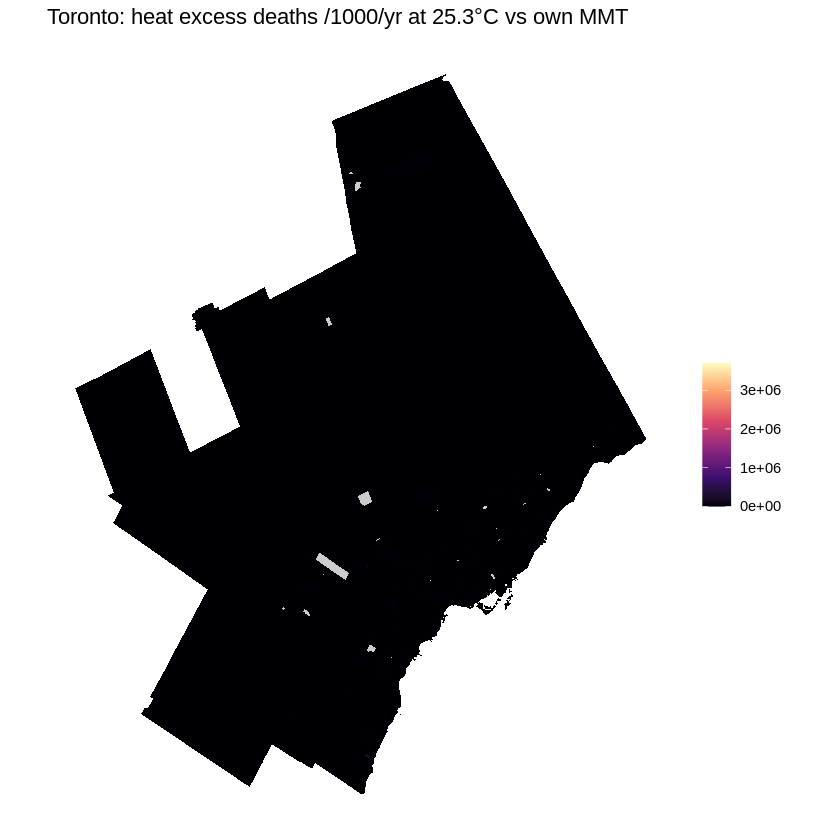

In [15]:
cdn_2011_std <- c(age_0_64 = 0.8210, age_65_74 = 0.0930, age_75_84 = 0.0580, age_85p = 0.0280)

T_heat <- unname(quantile(tor_sub$temp_mat, 0.95))
i_heat <- which.min(abs(grid - T_heat))
i_mmt  <- match(round(mmt_da, 1), round(grid, 1))
stopifnot(sum(is.na(i_mmt)) == 0)
ii <- seq_len(nrow(LR))
log_rr_heat <- LR[cbind(ii, i_heat)] - LR[cbind(ii, i_mmt)]
rr_heat <- exp(log_rr_heat)
cat("T_heat p95:", round(T_heat, 2), "| rr median", round(median(rr_heat), 2),
    "| IQR", round(quantile(rr_heat, c(.25, .75)), 2), "| max", round(max(rr_heat), 1),
    "| rr<1:", round(100 * mean(rr_heat < 1), 1), "%\n")

da_rates <- CJ(DAUID = tor_id, age_band = names(annual_rates))
da_rates[, rate := annual_rates[age_band] * (rr_heat[match(DAUID, tor_id)] - 1)]
std <- standardize_da_rate(da_rates)
stopifnot(nrow(std) == 7682, sum(is.na(std$std_rate)) == 0)
cat("std excess rate /1000/yr: median", round(median(std$std_rate), 2),
    "| range", round(range(std$std_rate), 2), "\n")

stopifnot(identical(tor_sub$truth_factors$DAUID, tor_id))
truth_tor <- with(tor_sub$truth_factors, 0.4 * F1 + 0.2 * F3)
cat("read only, not scored: pearson(log rr_heat, truth):", round(cor(log_rr_heat, truth_tor), 3), "\n")

tor_sf <- st_read(file.path(DRIVE, "toronto_da.geojson"), quiet = TRUE)
tor_sf$DAUID <- as.character(tor_sf$DAUID)
tor_sf <- merge(tor_sf, as.data.frame(std), by = "DAUID", all.x = TRUE)
cat("polys:", nrow(tor_sf), "| attached:", sum(!is.na(tor_sf$std_rate)), "\n")
p_map <- make_choropleth(tor_sf, "std_rate",
                         sprintf("Toronto: heat excess deaths /1000/yr at %.1f°C vs own MMT", T_heat))
ggsave("/content/fig3_map.png", p_map, width = 8, height = 7, dpi = 130)
print(p_map)
cat("fig3_map.png:", file.exists("/content/fig3_map.png"), "\n")

T_heat p95: 25.32 | rr median 1.82 | IQR 1.08 4.61 | max 395848.2 | rr<1: 0 %
std excess rate /1000/yr: median 7.64 | range 0 3709286
read only, not scored: pearson(log rr_heat, truth): -0.594
polys: 7716 | attached: 7682
Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.”
fig3_map.png: TRUE

---

first map drawn. T_heat 25.32, rr median 1.82, IQR 1.08 to 4.61, max 395,848: a handful of DAs with mmt near 16.6 read heat nine degrees above their minimum on a tilted curve and set the palette, so the map renders black. rr<1 zero, all 7,682 attached. pearson −0.594 read only, sign unchanged from §11.4 because the pool is unchanged

same map, fill on log10(1 + std_rate) so the outliers stop owning the palette. quantiles printed for the legend. overwrites fig3_map.png

log10(1+rate): q10 0.05 | q25 0.24 | median 0.94 | q75 1.54 | q99 3.32 | max 6.57 
fig3_map.png: TRUE 


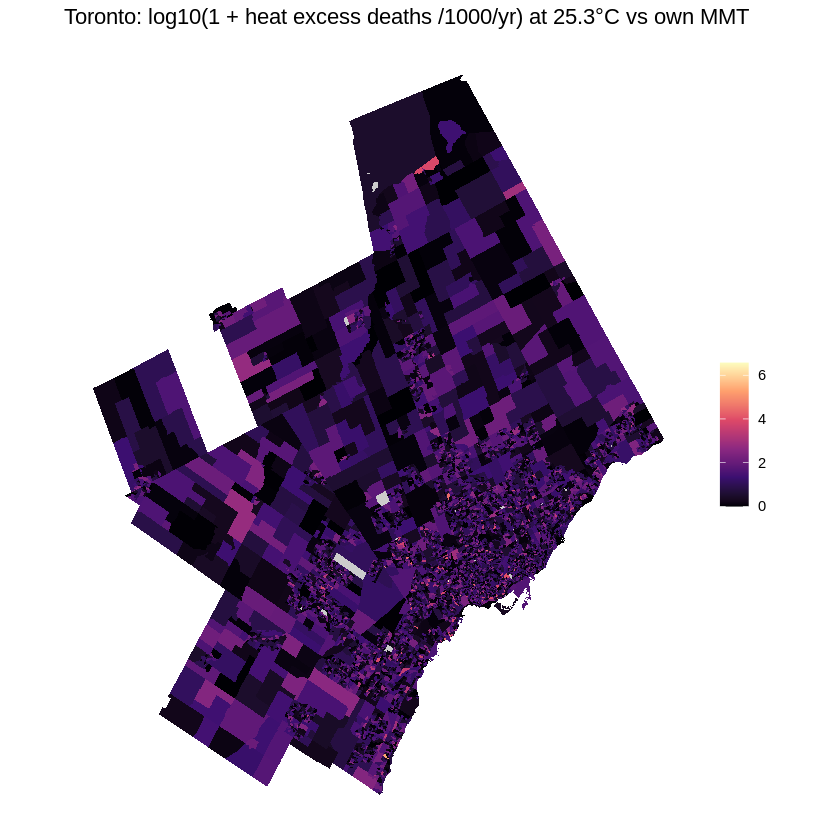

In [16]:
tor_sf$log_rate <- log10(1 + tor_sf$std_rate)
q <- quantile(tor_sf$log_rate, c(.10, .25, .50, .75, .99, 1), na.rm = TRUE)
cat("log10(1+rate): q10", round(q[1], 2), "| q25", round(q[2], 2), "| median", round(q[3], 2),
    "| q75", round(q[4], 2), "| q99", round(q[5], 2), "| max", round(q[6], 2), "\n")
p_map <- ggplot(tor_sf) +
  geom_sf(aes(fill = log_rate), color = NA) +
  scale_fill_viridis_c(option = "magma", na.value = "grey80") +
  theme_minimal(base_size = 11) +
  labs(title = sprintf("Toronto: log10(1 + heat excess deaths /1000/yr) at %.1f°C vs own MMT", T_heat),
       fill = NULL) +
  theme(panel.grid = element_blank(), axis.text = element_blank(), axis.title = element_blank())
ggsave("/content/fig3_map.png", p_map, width = 8, height = 7, dpi = 130)
print(p_map)
cat("fig3_map.png:", file.exists("/content/fig3_map.png"), "\n")

log10(1+rate): q10 0.05 | q25 0.24 | median 0.94 | q75 1.54 | q99 3.32 | max 6.57
fig3_map.png: TRUE

---

same surface on log10: median 0.94, q75 1.54, q99 3.32, max 6.57. patchwork, no spatial pattern, which is the dgp: iid factors, no geography. a handful of bright DAs are the outliers from the tilted curves. first readable map of the pipeline, sign still −0.59, not scored

save_to_drive with unlink above dir.create so the tarball holds only today. bank slim: key_in, key5 v3, curves v3, se5, ladder_tab, cma_bu, stage2_bu, th_bu, mmt_da, da_surface. three pngs copied to drive

In [17]:
save_to_drive <- function(objs, tag = format(Sys.Date(), "%Y-%m-%d"), drive = DRIVE) {
  unlink("/content/saves_eod", recursive = TRUE)
  dir.create("/content/saves_eod", showWarnings = FALSE)
  for (nm in names(objs)) saveRDS(objs[[nm]], sprintf("/content/saves_eod/%s.rds", nm))
  tarball <- sprintf("saves_eod_%s.tar.gz", tag)
  system(sprintf("cd /content && tar -czf %s saves_eod/ && cp %s '%s/'", tarball, tarball, drive))
  cat("saved", length(objs), "objects ->", file.path(drive, tarball), "\n")
}

da_surface <- data.table(DAUID = tor_id, mmt = mmt_da, log_rr_heat = log_rr_heat,
                         rr_heat = rr_heat, std_rate = std$std_rate[match(tor_id, std$DAUID)],
                         T_heat = T_heat)
stopifnot(nrow(da_surface) == 7682, sum(is.na(da_surface)) == 0)

save_to_drive(list(key_in = key_in, key5_v3 = key5, curves_v3 = curves, se5 = se5,
                   ladder_tab = ladder_tab, cma_bu = cma_bu, stage2_bu = stage2_bu,
                   th_bu = th_bu, mmt_da = mmt_da, da_surface = da_surface),
              tag = "2026-08-26")
cat("rds in tarball:", length(list.files("/content/saves_eod", pattern = "\\.rds$")),
    "| size MB:", round(file.info("/content/saves_eod_2026-08-26.tar.gz")$size / 1024^2, 1), "\n")
cat("pngs copied:", file.copy(c("/content/fig3_map.png", "/content/fig_key5.png", "/content/fig_ladder_tor.png"),
                             file.path(DRIVE, c("fig3_map_2026-08-26.png", "fig_key5_2026-08-26.png",
                                                "fig_ladder_tor_2026-08-26.png")), overwrite = TRUE), "\n")

saved 10 objects -> /content/drive/MyDrive/thesis/dlnm-pilot/saves_eod_2026-08-26.tar.gz 
rds in tarball: 10 | size MB: 0.5 
pngs copied: TRUE TRUE TRUE 


saved 10 objects -> /content/drive/MyDrive/thesis/dlnm-pilot/saves_eod_2026-08-26.tar.gz
rds in tarball: 10 | size MB: 0.5
pngs copied: TRUE TRUE TRUE

---

saves_eod_2026-08-26: ten objects, 0.5 MB, tarball holds only today. unlink above dir.create is the fns.R change. three figures on drive with the date